# R2 analyse - Tableau et plot

In [1]:
import sys
sys.path.insert(0, '../')

import pandas as pd
import numpy as np

df_LOPO_AE_entr = pd.read_csv("../reports/results_leave_one_name_out.csv")

df_LOPO_AE_gele = pd.read_csv("../reports/results_leave_one_name_out_AE_froze.csv")

In [2]:
df_LOPO_AE_entr.head()

,target,R2_test,RMSE_test,MAE_test,model,nom_test
0,EB (kcal) kcal/kg brut,0.915690,125.335004,91.460640,MLP,Farine de viande (toutes)
1,ED porc croissance (kcal) kcal/kg brut,0.662470,306.717781,229.645691,MLP,Farine de viande (toutes)
2,EM porc croissance (kcal) kcal/kg brut,0.636865,296.022948,222.878662,MLP,Farine de viande (toutes)
3,EN porc croissance (kcal) kcal/kg brut,0.808692,144.329220,103.513847,MLP,Farine de viande (toutes)
4,EMAn coq (kcal) kcal/kg brut,0.597917,250.882396,224.105408,MLP,Farine de viande (toutes)


In [3]:
def prepare_mean_r2(df, condition_name):
    df_mean = (
        df
        .groupby(["model", "nom_test"])["R2_test"]
        .mean()
        .reset_index()
    )
    df_mean["condition"] = condition_name
    return df_mean

In [4]:
df_entr_mean = prepare_mean_r2(df_LOPO_AE_entr, "AE_entraine")
df_gele_mean = prepare_mean_r2(df_LOPO_AE_gele, "AE_gele")

df_all = pd.concat([df_entr_mean, df_gele_mean], ignore_index=True)

df_all["group"] = df_all["model"] + " - " + df_all["condition"]

C:\Users\grani\AppData\Local\Temp\ipykernel_32064\1953730883.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


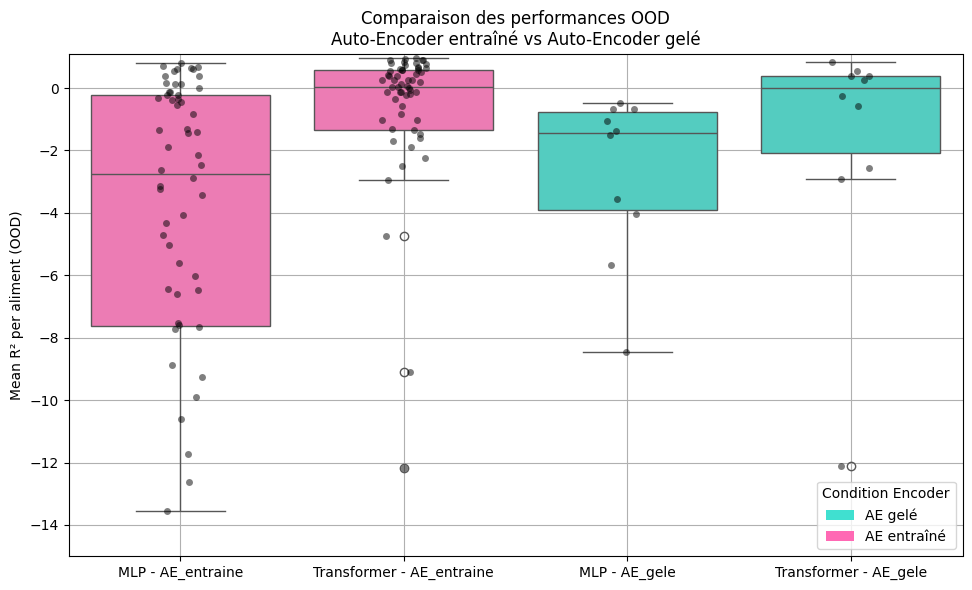

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

palette = {
    "MLP - AE_gele": "#40E0D0",          # turquoise
    "Transformer - AE_gele": "#40E0D0",
    "MLP - AE_entraine": "#FF69B4",      # rose
    "Transformer - AE_entraine": "#FF69B4"
}



plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_all,
    x="group",
    y="R2_test",
    palette=palette
)

sns.stripplot(
    data=df_all,
    x="group",
    y="R2_test",
    color="black",
    alpha=0.5
)

plt.ylabel("Mean R² per aliment (OOD)")
plt.xlabel("")
plt.title("Comparaison des performances OOD\nAuto-Encoder entraîné vs Auto-Encoder gelé")

plt.xticks(rotation=0)

# =========================
# Légende personnalisée
# =========================

legend_elements = [
    Patch(facecolor="#40E0D0", label="AE gelé"),
    Patch(facecolor="#FF69B4", label="AE entraîné")
]

plt.legend(handles=legend_elements, title="Condition Encoder")

plt.tight_layout()
plt.ylim(-15,1.1)
plt.grid()
plt.show()

C:\Users\grani\AppData\Local\Temp\ipykernel_32064\157762874.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


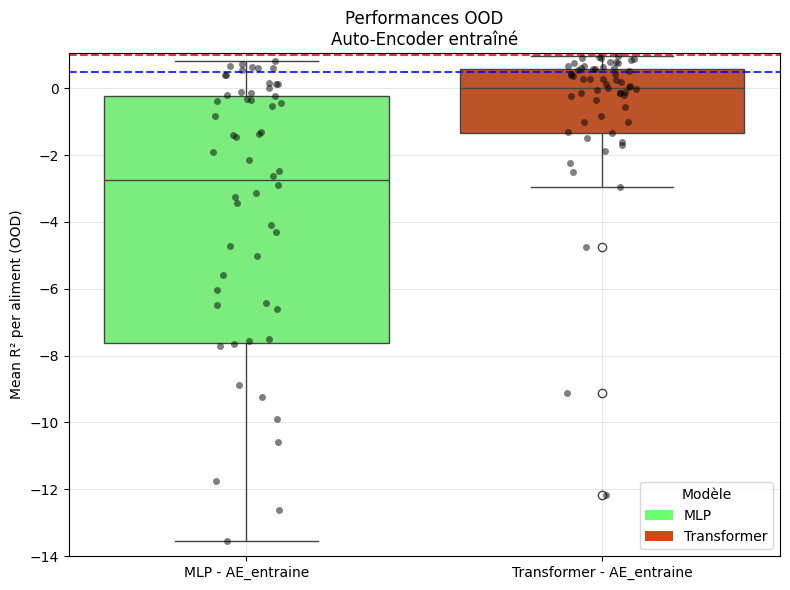

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# =========================
# Filtrage : AE entraîné uniquement
# =========================
df_plot = df_all[df_all["condition"] == "AE_entraine"].copy()

order = ["MLP - AE_entraine", "Transformer - AE_entraine"]

palette = {
    "MLP - AE_entraine": "#69FF6C",
    "Transformer - AE_entraine": "#D44811"
}

plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=df_plot,
    x="group",
    y="R2_test",
    order=order,
    palette=palette
)

sns.stripplot(
    data=df_plot,
    x="group",
    y="R2_test",
    order=order,
    color="black",
    alpha=0.5
)

# =========================
# Ligne horizontale à R² = 1
# =========================
plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# =========================
plt.axhline(
    y=0.5,
    color="blue",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

plt.ylabel("Mean R² per aliment (OOD)")
plt.xlabel("")
plt.title("Performances OOD\nAuto-Encoder entraîné")

plt.ylim(-14, 1.05)
plt.grid(alpha=0.3)

legend_elements = [
    Patch(facecolor="#69FF6C", label="MLP"),
    Patch(facecolor="#D44811", label="Transformer")
]

plt.legend(handles=legend_elements, title="Modèle")

plt.tight_layout()
plt.show()

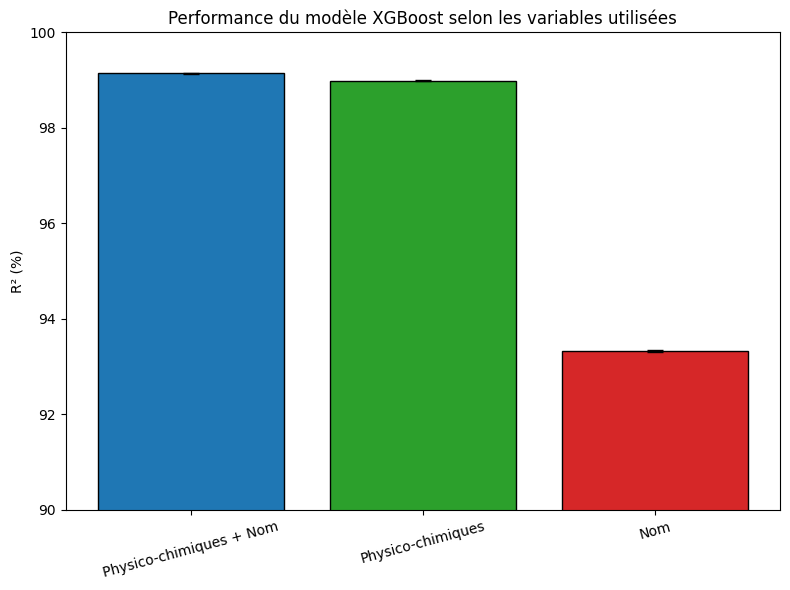

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Données
labels = [
    "Physico-chimiques + Nom",
    "Physico-chimiques",
    "Nom"
]

means = [99.14, 98.99, 93.33]
stds  = [0.0024, 0.0021, 0.0196]

# Couleurs personnalisées
colors = [
    "#1f77b4",  # bleu profond
    "#2ca02c",  # vert
    "#d62728"   # rouge
]

# Plot
plt.figure(figsize=(8,6))

bars = plt.bar(
    labels,
    means,
    yerr=stds,
    capsize=6,
    color=colors,
    edgecolor="black"
)

plt.ylabel("R² (%)")
plt.title("Performance du modèle XGBoost selon les variables utilisées")

plt.ylim(90, 100)

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

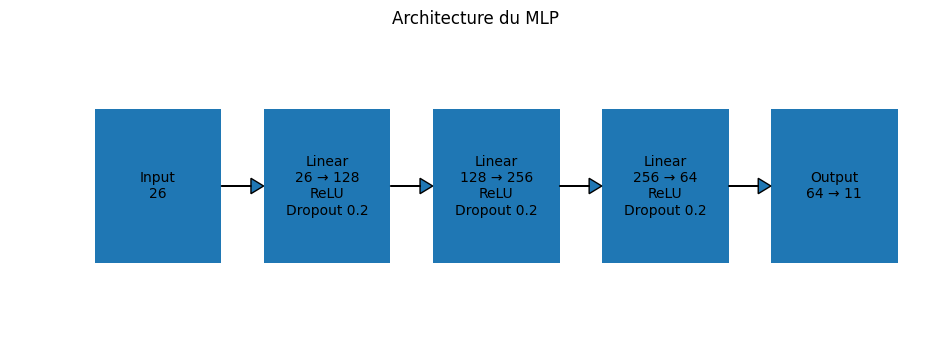

In [17]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

layers = [
    "Input\n26",
    "Linear\n26 → 128\nReLU\nDropout 0.2",
    "Linear\n128 → 256\nReLU\nDropout 0.2",
    "Linear\n256 → 64\nReLU\nDropout 0.2",
    "Output\n64 → 11"
]

plt.figure(figsize=(12,4))
ax = plt.gca()

for i, layer in enumerate(layers):
    rect = Rectangle((i*2, 0), 1.5, 1, fill=True)
    ax.add_patch(rect)
    ax.text(i*2 + 0.75, 0.5, layer,
            ha='center', va='center')

for i in range(len(layers)-1):
    plt.arrow(i*2+1.5, 0.5, 0.5, 0,
              head_width=0.1, length_includes_head=True)

plt.xlim(-1, len(layers)*2)
plt.ylim(-0.5, 1.5)
plt.axis("off")
plt.title("Architecture du MLP")
plt.show()

In [ ]:
All_var = [.98, .99, .99, .991, .987, 0.988, 0.991, 0.986, 0.996, 0.996, 0.996]

Random_var = [.988,0.991, 0.990, 0.989, 0.984, 0.995, 0.988, 0.989, 0.993, 0.993, 0.994 ]

None_var = [.965,  .9645, .0.95, 0.946, 0.947, 0.953, 0.96, 0.963, 0.99, 0.989, 0.987 ]

C:\Users\grani\AppData\Local\Temp\ipykernel_32064\1417203748.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


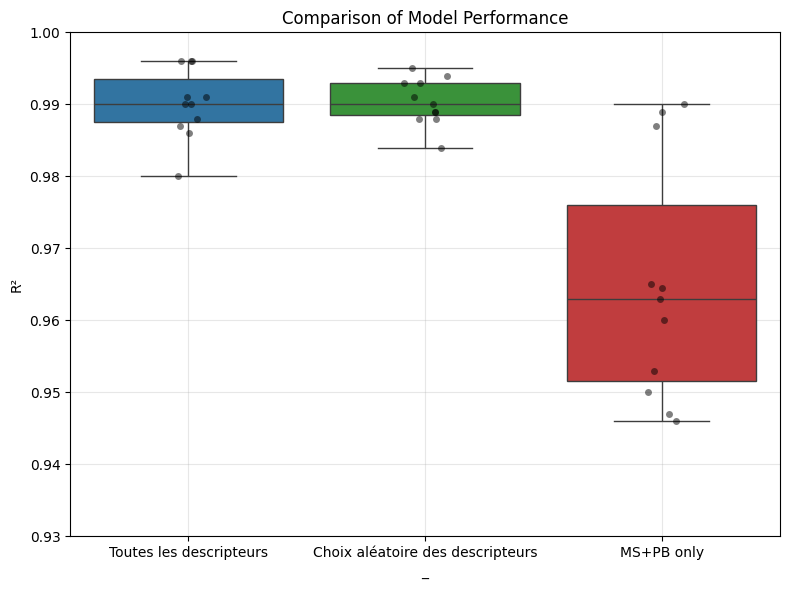

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Données
All_var = [0.98, 0.99, 0.99, 0.991, 0.987, 0.988, 0.991, 0.986, 0.996, 0.996, 0.996]
Random_var = [0.988, 0.991, 0.990, 0.989, 0.984, 0.995, 0.988, 0.989, 0.993, 0.993, 0.994]
None_var = [0.965, 0.9645, 0.95, 0.946, 0.947, 0.953, 0.96, 0.963, 0.99, 0.989, 0.987]

# Format long
df = pd.DataFrame({
    "R2": All_var + Random_var + None_var,
    "_": (
        ["Toutes les descripteurs"] * len(All_var) +
        ["Choix aléatoire des descripteurs"] * len(Random_var) +
        ["MS+PB only"] * len(None_var)
    )
})

# Palette personnalisable
palette = {
    "Toutes les descripteurs": "#1f77b4",   # bleu
    "Choix aléatoire des descripteurs": "#2ca02c", # vert
    "MS+PB only": "#d62728"      # rouge
}

# Plot
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x = "_",
    y="R2",
    palette=palette
)

sns.stripplot(
    data=df,
    x="_",
    y="R2",
    color="black",
    alpha=0.5
)

plt.ylabel("R²")
plt.title("Comparison of Model Performance")

plt.ylim(0.93, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
r2_none = [
    0.809,
    -1.351,
    -1.651,
    -5.569,
    -6.208,
    -12.190,
    0.098,
    -0.427,
    0.612,
    0.335,
    0.920
]

r2_partial = [
    0.725,
    -4.595,
    -5.478,
    -13.414,
    -9.737,
    -17.401,
    -2.523,
    -4.054,
    0.599,
    0.298,
    -0.016
]

r2_total = [
    0.118,
    -26.792,
    -31.533,
    -64.829,
    -32.885,
    -44.192,
    -16.215,
    -23.186,
    -0.183,
    0.153,
    -6.029
]

C:\Users\grani\AppData\Local\Temp\ipykernel_32064\3815345779.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


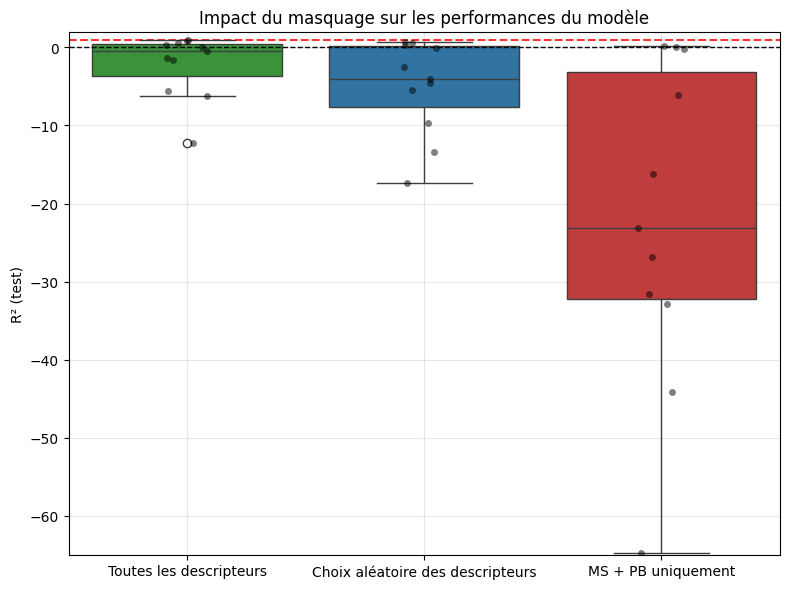

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# R² des 3 scénarios
# =========================

r2_none = [
    0.809,
    -1.351,
    -1.651,
    -5.569,
    -6.208,
    -12.190,
    0.098,
    -0.427,
    0.612,
    0.335,
    0.920
]

r2_partial = [
    0.725,
    -4.595,
    -5.478,
    -13.414,
    -9.737,
    -17.401,
    -2.523,
    -4.054,
    0.599,
    0.298,
    -0.016
]

r2_total = [
    0.118,
    -26.792,
    -31.533,
    -64.829,
    -32.885,
    -44.192,
    -16.215,
    -23.186,
    -0.183,
    0.153,
    -6.029
]

# =========================
# DataFrame long format
# =========================

df_box = pd.DataFrame({
    "R2": r2_none + r2_partial + r2_total,
    "Configuration": (
        ["Toutes les descripteurs"] * len(r2_none) +
        ["Choix aléatoire des descripteurs"] * len(r2_partial) +
        ["MS + PB uniquement"] * len(r2_total)
    )
})

order = [
    "Toutes les descripteurs",
    "Choix aléatoire des descripteurs",
    "MS + PB uniquement"
]

# =========================
# Palette personnalisée
# =========================

palette = {
    "Toutes les descripteurs": "#2ca02c",        # vert
    "Choix aléatoire des descripteurs": "#1f77b4",   # bleu
    "MS + PB uniquement": "#d62728"       # rouge
}

# =========================
# Plot
# =========================

plt.figure(figsize=(8,6))

plt.axhline(
    y=1,
    color="red",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

# =========================


sns.boxplot(
    data=df_box,
    x="Configuration",
    y="R2",
    order=order,
    palette=palette
)

sns.stripplot(
    data=df_box,
    x="Configuration",
    y="R2",
    order=order,
    color="black",
    alpha=0.5
)

# Ligne R² = 0
plt.axhline(y=0, color="black", linestyle="--", linewidth=1)
plt.ylim((-65,2))

plt.ylabel("R² (test)")
plt.xlabel("")
plt.title("Impact du masquage sur les performances du modèle")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()